# The Distribution Zoo

A tour of occhio's distribution types -- from simple sparse baselines to
curved manifolds, compositional simplices, correlated hierarchies, and
graph-structured cascades.  Each distribution imposes a different
statistical and geometric structure on the data.  The question we
explore throughout: **how does the structure of your data determine
the structure of the learned representation?**

For each distribution we:
1. Create the distribution and sample data
2. Inspect its statistical fingerprint (sparsity, mean activation)
3. Train a TiedLinearRelu autoencoder
4. Report final loss and superposition
5. Examine the learned feature norms

We finish with a comparison table and chart across all six distributions.

Requires: `pip install occhio`

In [1]:
import torch
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "png"

from occhio import ToyModel
from occhio.autoencoders import TiedLinearRelu
from occhio.distributions import (
    SparseUniform,
    HierarchicalPairs,
    ToricDistribution,
    SphericalDistribution,
    SimplexDistribution,
    PreferentialAttachment,
)

torch.manual_seed(42)

In [2]:
# -- Shared parameters -------------------------------------------------------

N_FEATURES = 50
N_HIDDEN = 15
N_EPOCHS = 25000
LEARNING_RATE = 3e-4
P_ACTIVE = 0.01
BATCH_SIZE = 1024
DEVICE = "cpu"


def data_fingerprint(dist, name, n_samples=4096):
    """Print basic statistics about a distribution's samples."""
    x = dist.sample(n_samples)
    sparsity = (x == 0).float().mean().item()
    active_per_sample = (x > 0).float().sum(dim=1)
    mean_activation = x[x > 0].mean().item() if (x > 0).any() else 0.0

    print(f"--- {name} ---")
    print(f"  Shape:            {list(x.shape)}")
    print(f"  Sparsity:         {sparsity:.3f}")
    print(f"  Mean active/sample: {active_per_sample.mean():.1f} / {x.shape[1]}")
    print(f"  Mean activation:  {mean_activation:.4f}")
    print()
    return x


def train_and_report(dist, name):
    """Train a TiedLinearRelu AE and return the ToyModel + losses."""
    gen = torch.Generator(DEVICE).manual_seed(42)

    ae = TiedLinearRelu(
        n_features=dist.n_features,
        n_hidden=N_HIDDEN,
        device=DEVICE,
        generator=gen,
    )
    tm = ToyModel(dist, ae, device=DEVICE)
    losses, _ = tm.fit(
        n_epochs=N_EPOCHS,
        learning_rate=LEARNING_RATE,
        batch_size=BATCH_SIZE,
    )

    final_loss = losses[-1]
    norms = tm.feature_norms
    superposition = tm.superposition.item()

    print(f"--- {name}: Training Results ---")
    print(f"  Final loss:       {final_loss:.6f}")
    print(f"  Superposition:    {superposition:.3f}")
    print(f"  Feature norms:    [{norms.min():.3f}, {norms.max():.3f}]")
    print(f"  Mean norm:        {norms.mean():.3f}  (std {norms.std():.3f})")
    print()
    return tm, losses


def plot_feature_norms(tm, title):
    """Bar chart of per-feature norms."""
    norms = tm.feature_norms.detach().cpu().numpy()
    fig = go.Figure(
        data=go.Bar(
            x=list(range(len(norms))),
            y=norms,
            marker_color="steelblue",
        )
    )
    fig.update_layout(
        title=title,
        xaxis_title="Feature index",
        yaxis_title="Norm",
        height=300,
        width=700,
    )
    fig.show()
    return fig

---
## 1. SparseUniform (Baseline)

The simplest distribution: each feature fires independently with
probability `p_active` and takes a `Uniform(0, 1)` value when active.
No correlations, no geometry -- just independent sparse features.
This is our baseline for comparison.

In [3]:
sparse_dist = SparseUniform(
    n_features=N_FEATURES,
    p_active=P_ACTIVE,
    device=DEVICE,
)

x_sparse = data_fingerprint(sparse_dist, "SparseUniform")

--- SparseUniform ---
  Shape:            [4096, 50]
  Sparsity:         0.990
  Mean active/sample: 0.5 / 50
  Mean activation:  0.5002



Training SparseUniform...


--- SparseUniform: Training Results ---
  Final loss:       0.007090
  Superposition:    0.558
  Feature norms:    [1.103, 1.119]
  Mean norm:        1.113  (std 0.003)



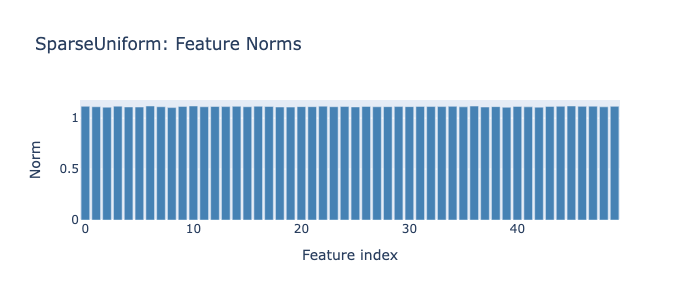

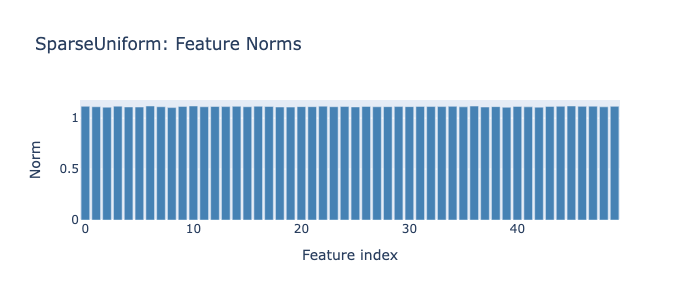

In [4]:
print("Training SparseUniform...")
tm_sparse, losses_sparse = train_and_report(sparse_dist, "SparseUniform")
plot_feature_norms(tm_sparse, "SparseUniform: Feature Norms")

---
## 2. HierarchicalPairs (Correlated Features)

Features are organized in parent-child pairs: (0,1), (2,3), ...
The parent activates with probability `p_active`, and the child
fires only when the parent is active (with probability `p_follow`).
The `beta` parameter controls magnitude coupling -- at `beta=0.8`
the child's value is tightly tied to the parent's.

This creates positive within-pair correlations while keeping
different pairs independent.  The autoencoder must decide whether
to represent correlated features together or separately.

Note: `n_features` must be even for pairs.

In [5]:
hier_dist = HierarchicalPairs(
    n_features=N_FEATURES,
    p_active=P_ACTIVE,
    p_follow=0.7,
    beta=0.8,
    device=DEVICE,
)

x_hier = data_fingerprint(hier_dist, "HierarchicalPairs")

# Verify the correlation structure
corr_hier = torch.corrcoef(x_hier.T)
pair_corrs = [corr_hier[2 * i, 2 * i + 1].item() for i in range(N_FEATURES // 2)]
print(
    f"  Within-pair correlations: mean={np.mean(pair_corrs):.3f},"
    f" range=[{min(pair_corrs):.3f}, {max(pair_corrs):.3f}]"
)

--- HierarchicalPairs ---
  Shape:            [4096, 50]
  Sparsity:         0.992
  Mean active/sample: 0.4 / 50
  Mean activation:  0.5082

  Within-pair correlations: mean=0.822, range=[0.617, 0.925]


Training HierarchicalPairs...


--- HierarchicalPairs: Training Results ---
  Final loss:       0.003747
  Superposition:    0.726
  Feature norms:    [0.977, 1.039]
  Mean norm:        1.004  (std 0.016)



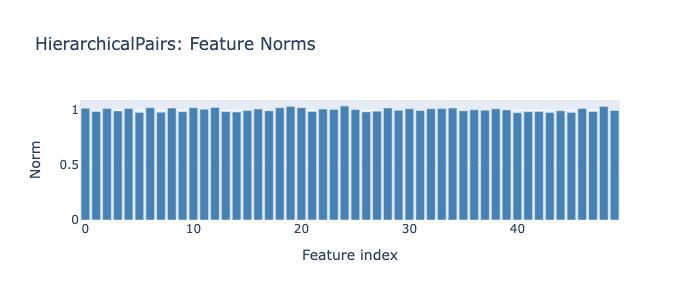

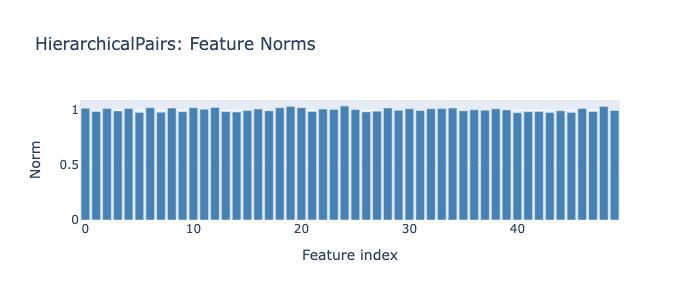

In [6]:
print("Training HierarchicalPairs...")
tm_hier, losses_hier = train_and_report(hier_dist, "HierarchicalPairs")
plot_feature_norms(tm_hier, "HierarchicalPairs: Feature Norms")

---
## 3. ToricDistribution (Periodic Manifold)

Features are placed at random angles on a 1D torus (circle with
flat/geodesic metric).  Sampling picks a random point on the torus
and activates nearby features with a cosine bump profile.  The
`length_scale` controls how many features light up per sample --
smaller values give sparser activations.

The key geometric property: the torus introduces *local* correlations
between angularly adjacent features, and the activation pattern
wraps around periodically.

In [7]:
toric_dist = ToricDistribution(
    n_features=N_FEATURES,
    length_scale=0.4,
    toric_dim=1,
    device=DEVICE,
)

x_toric = data_fingerprint(toric_dist, "ToricDistribution")

--- ToricDistribution ---
  Shape:            [4096, 50]
  Sparsity:         0.799
  Mean active/sample: 10.0 / 50
  Mean activation:  0.6039



Training ToricDistribution...


--- ToricDistribution: Training Results ---
  Final loss:       0.000156
  Superposition:    0.736
  Feature norms:    [0.475, 0.933]
  Mean norm:        0.727  (std 0.112)



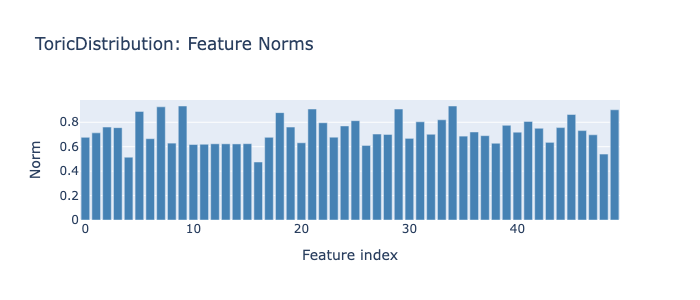

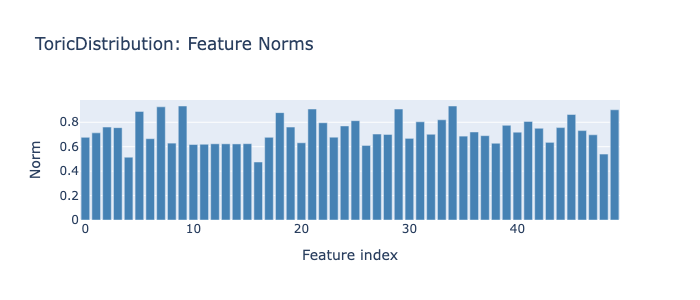

In [8]:
print("Training ToricDistribution...")
tm_toric, losses_toric = train_and_report(toric_dist, "ToricDistribution")
plot_feature_norms(tm_toric, "ToricDistribution: Feature Norms")

---
## 4. SphericalDistribution (Curved Manifold)

Features are placed at equal angular spacing on `S^1` (the unit
circle) or on higher-dimensional spheres.  Unlike the torus, the
sphere uses geodesic (angular) distance rather than flat distance.
With `manifold_dim=1` we get features on a circle -- each sample
picks a random direction and activates features within a cosine
bump of width `length_scale`.

The autoencoder must represent features that live on a *curved*
manifold.  With many more features than hidden dimensions, it
cannot preserve the full circular topology.

In [9]:
sphere_dist = SphericalDistribution(
    n_features=N_FEATURES,
    length_scale=0.4,
    manifold_dim=1,
    device=DEVICE,
)

x_sphere = data_fingerprint(sphere_dist, "SphericalDistribution")

--- SphericalDistribution ---
  Shape:            [4096, 50]
  Sparsity:         0.800
  Mean active/sample: 10.0 / 50
  Mean activation:  0.6051



Training SphericalDistribution...


--- SphericalDistribution: Training Results ---
  Final loss:       0.000030
  Superposition:    0.628
  Feature norms:    [0.524, 0.652]
  Mean norm:        0.590  (std 0.031)



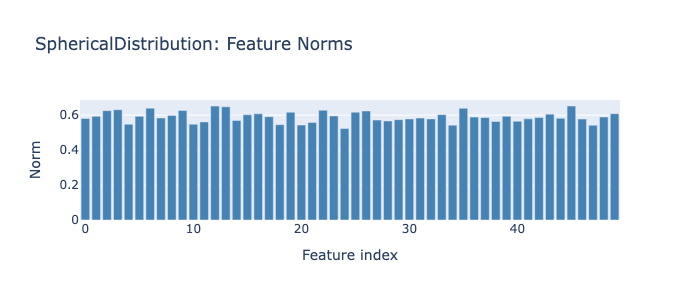

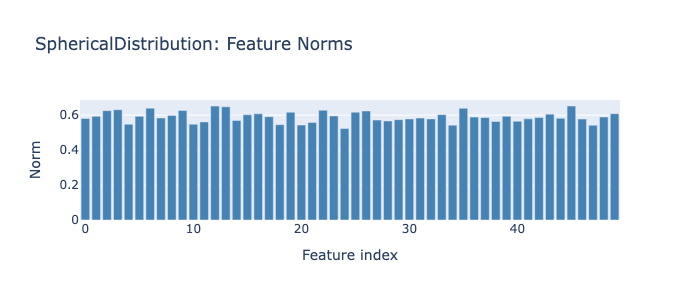

In [10]:
print("Training SphericalDistribution...")
tm_sphere, losses_sphere = train_and_report(sphere_dist, "SphericalDistribution")
plot_feature_norms(tm_sphere, "SphericalDistribution: Feature Norms")

---
## 5. SimplexDistribution (Compositional Constraint)

Features are partitioned into groups (simplices).  Each group fires
independently with probability `p_active`.  When a group fires, its
features are drawn from a symmetric Dirichlet distribution -- they
must sum to 1 within the group.  This is the natural distribution
for compositional data: market shares, mixture proportions, etc.

We partition 50 features into 10 groups of 5.  Each group fires
with probability matching our baseline `p_active`.

In [11]:
# 10 groups of 5 features each = 50 features total
simplex_sizes = [5] * 10

simplex_dist = SimplexDistribution(
    simplex_sizes=simplex_sizes,
    p_active=P_ACTIVE,
    device=DEVICE,
)

x_simplex = data_fingerprint(simplex_dist, "SimplexDistribution")

# When a group fires, all 5 of its features are nonzero (sum-to-1),
# so the active count jumps by 5. With p_active=0.01, most samples
# have 0 or 1 groups firing.
active_counts = (x_simplex > 0).float().sum(dim=1)
print(
    f"  Active count distribution:"
    f" median={active_counts.median():.0f},"
    f" max={active_counts.max():.0f}"
)

--- SimplexDistribution ---
  Shape:            [4096, 50]
  Sparsity:         0.991
  Mean active/sample: 0.5 / 50
  Mean activation:  0.2000

  Active count distribution: median=0, max=10


Training SimplexDistribution...


--- SimplexDistribution: Training Results ---
  Final loss:       0.001107
  Superposition:    0.655
  Feature norms:    [1.084, 1.105]
  Mean norm:        1.095  (std 0.005)



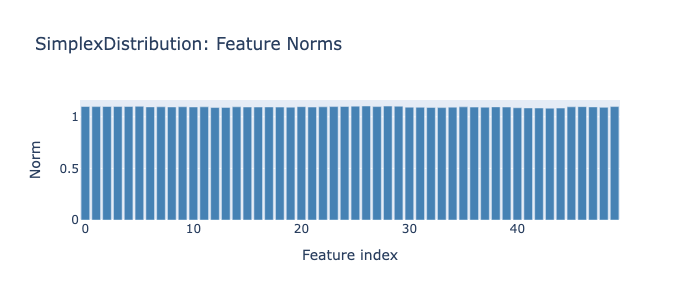

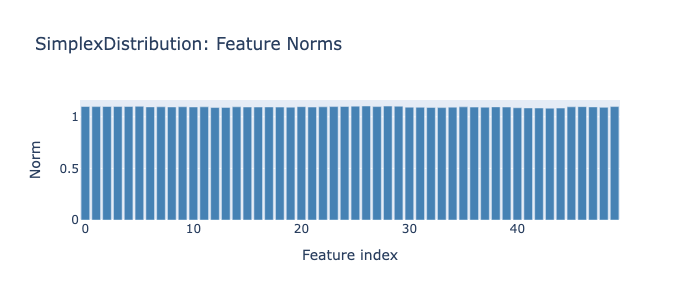

In [12]:
print("Training SimplexDistribution...")
tm_simplex, losses_simplex = train_and_report(simplex_dist, "SimplexDistribution")
plot_feature_norms(tm_simplex, "SimplexDistribution: Feature Norms")

---
## 6. PreferentialAttachment (Graph-Structured Cascades)

A directed graph with power-law in-degree distribution.  Node 0 has
the most in-edges (hub), and later nodes progressively fewer.
Each node fires independently with probability `p_active`, and then
active nodes cascade to their out-neighbors with probability
`p_child` (noisy-OR combination for multiple parents).

The `alpha` parameter controls the power-law exponent: `alpha=0`
gives Erdos-Renyi (uniform edges), `alpha=1` gives node 0 roughly
N times more in-edges than node N-1.

This creates heterogeneous activation frequencies and complex
correlation structure driven by the graph topology.

In [13]:
pa_gen = torch.Generator(DEVICE).manual_seed(123)

pa_dist = PreferentialAttachment(
    n_features=N_FEATURES,
    alpha=1.0,
    p_edge=0.15,
    p_active=P_ACTIVE,
    p_child=0.8,
    device=DEVICE,
    generator=pa_gen,
)

x_pa = data_fingerprint(pa_dist, "PreferentialAttachment")

# Show the in-degree distribution (power-law shape)
in_deg = pa_dist.in_degrees().cpu().numpy()
print(f"  In-degree: mean={in_deg.mean():.1f}, max={in_deg.max():.0f}")
print(f"  Top-5 hubs (by in-degree): {np.argsort(-in_deg)[:5]}")

--- PreferentialAttachment ---
  Shape:            [4096, 50]
  Sparsity:         0.959
  Mean active/sample: 2.1 / 50
  Mean activation:  0.4991

  In-degree: mean=4.0, max=11
  Top-5 hubs (by in-degree): [ 1 12 27  8  4]


Training PreferentialAttachment...


--- PreferentialAttachment: Training Results ---
  Final loss:       0.072290
  Superposition:    0.732
  Feature norms:    [0.889, 1.076]
  Mean norm:        0.986  (std 0.042)



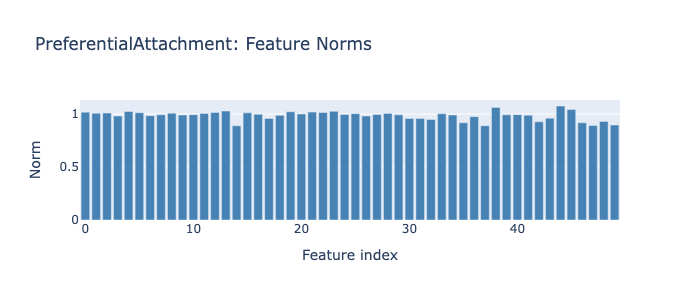

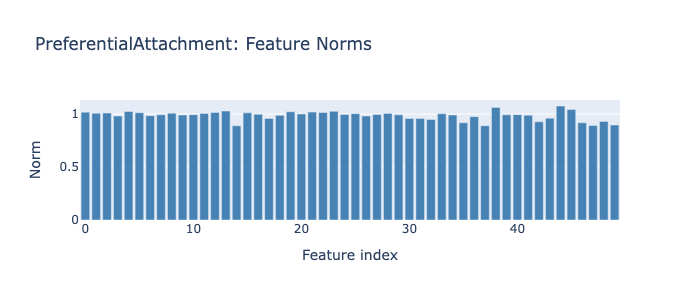

In [14]:
print("Training PreferentialAttachment...")
tm_pa, losses_pa = train_and_report(pa_dist, "PreferentialAttachment")
plot_feature_norms(tm_pa, "PreferentialAttachment: Feature Norms")

---
## Comparison: How Data Structure Shapes Representation

Let's bring all six distributions together and compare how the
autoencoder responds to each one.

In [15]:
# -- Summary table -----------------------------------------------------------

results = {
    "SparseUniform": (tm_sparse, losses_sparse),
    "HierarchicalPairs": (tm_hier, losses_hier),
    "ToricDistribution": (tm_toric, losses_toric),
    "SphericalDistribution": (tm_sphere, losses_sphere),
    "SimplexDistribution": (tm_simplex, losses_simplex),
    "PreferentialAttachment": (tm_pa, losses_pa),
}

print(
    f"{'Distribution':<24} {'Loss':>10} {'Superpos.':>10}"
    f" {'Norm min':>10} {'Norm max':>10} {'Norm mean':>10}"
)
print("-" * 76)

for name, (tm, losses) in results.items():
    norms = tm.feature_norms
    print(
        f"{name:<24} {losses[-1]:>10.6f} {tm.superposition.item():>10.3f}"
        f" {norms.min():>10.3f} {norms.max():>10.3f}"
        f" {norms.mean():>10.3f}"
    )

Distribution                   Loss  Superpos.   Norm min   Norm max  Norm mean
----------------------------------------------------------------------------
SparseUniform              0.007090      0.558      1.103      1.119      1.113
HierarchicalPairs          0.003747      0.726      0.977      1.039      1.004
ToricDistribution          0.000156      0.736      0.475      0.933      0.727
SphericalDistribution      0.000030      0.628      0.524      0.652      0.590
SimplexDistribution        0.001107      0.655      1.084      1.105      1.095
PreferentialAttachment     0.072290      0.732      0.889      1.076      0.986


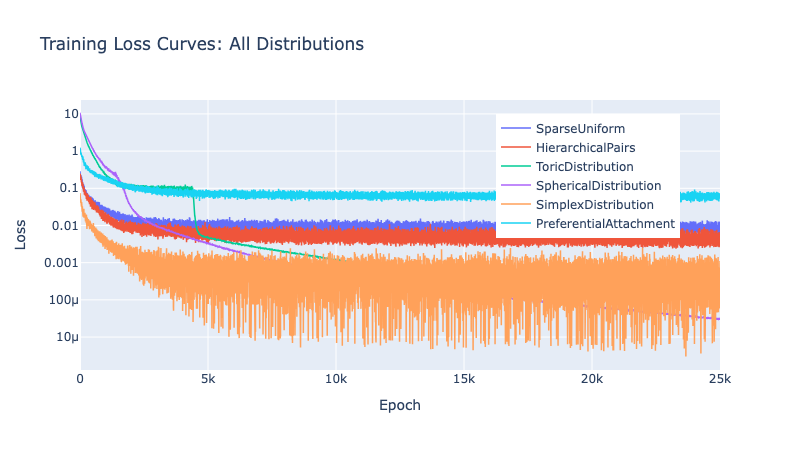

In [16]:
# -- Comparison: loss curves -------------------------------------------------

fig = go.Figure()
for name, (tm, losses) in results.items():
    fig.add_trace(
        go.Scatter(
            y=losses,
            mode="lines",
            name=name,
            line=dict(width=1.5),
        )
    )
fig.update_layout(
    title="Training Loss Curves: All Distributions",
    xaxis_title="Epoch",
    yaxis_title="Loss",
    yaxis_type="log",
    height=450,
    width=800,
    legend=dict(x=0.65, y=0.95),
)
fig.show()

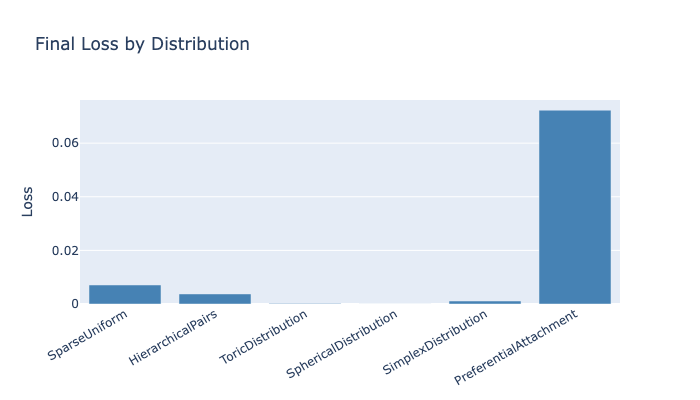

In [17]:
# -- Comparison: final loss bar chart ----------------------------------------

names = list(results.keys())
final_losses = [results[n][1][-1] for n in names]
superpositions = [results[n][0].superposition.item() for n in names]

fig = go.Figure(
    data=[
        go.Bar(
            name="Final Loss",
            x=names,
            y=final_losses,
            marker_color="steelblue",
        ),
    ]
)
fig.update_layout(
    title="Final Loss by Distribution",
    yaxis_title="Loss",
    height=400,
    width=700,
    xaxis_tickangle=-30,
)
fig.show()

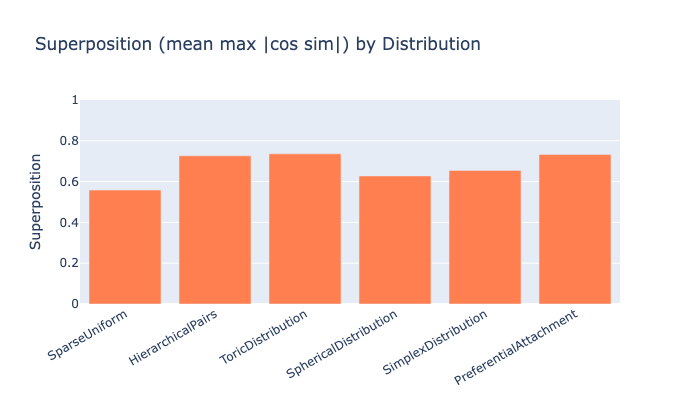

In [18]:
# -- Comparison: superposition bar chart -------------------------------------

fig = go.Figure(
    data=[
        go.Bar(
            name="Superposition",
            x=names,
            y=superpositions,
            marker_color="coral",
        ),
    ]
)
fig.update_layout(
    title="Superposition (mean max |cos sim|) by Distribution",
    yaxis_title="Superposition",
    yaxis_range=[0, 1],
    height=400,
    width=700,
    xaxis_tickangle=-30,
)
fig.show()

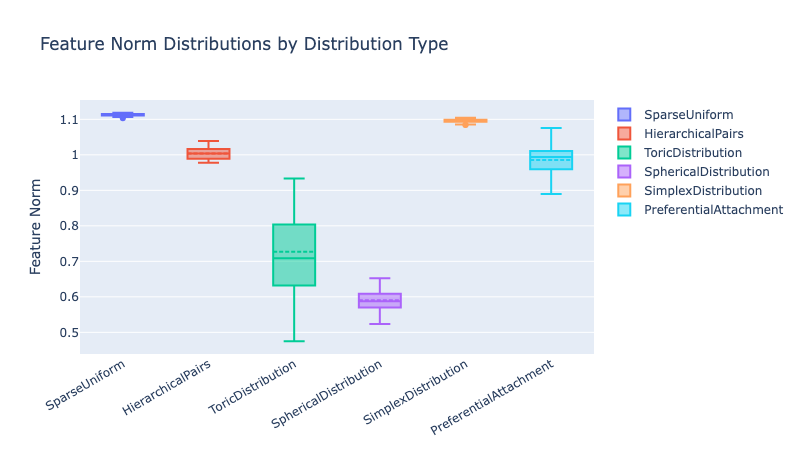

In [19]:
# -- Comparison: feature norm distributions ----------------------------------

fig = go.Figure()
for name, (tm, _) in results.items():
    norms = tm.feature_norms.detach().cpu().numpy()
    fig.add_trace(
        go.Box(
            y=norms,
            name=name,
            boxmean=True,
        )
    )
fig.update_layout(
    title="Feature Norm Distributions by Distribution Type",
    yaxis_title="Feature Norm",
    height=450,
    width=800,
    xaxis_tickangle=-30,
)
fig.show()

**Key observations:**

- **SparseUniform** is the baseline: independent features with no
  structure.  The autoencoder has maximum freedom in how it packs
  features into the bottleneck.

- **HierarchicalPairs** introduces within-pair correlations.  The
  autoencoder can exploit these by aligning correlated features,
  potentially reducing effective dimensionality.

- **Toric and Spherical** distributions create local manifold
  structure -- nearby features on the manifold co-activate.  The
  learned norms and interference patterns should reflect the
  underlying topology.

- **SimplexDistribution** produces compositional data where features
  within a group sum to 1.  The sum-to-one constraint creates
  within-group dependencies that the autoencoder must accommodate.

- **PreferentialAttachment** creates heterogeneous activation
  frequencies via graph cascades.  Hub nodes (high in-degree)
  activate more often, and the autoencoder may allocate more
  representation capacity (higher norms) to frequently active
  features.

The punchline: the structure of your data influences the structure
of the learned representation.  Different distributions produce
different loss landscapes, superposition levels, and feature norm
profiles -- even when the feature count, hidden dimension, and
training budget are held constant.